In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace import sarimax
from statsmodels.tsa.api import ExponentialSmoothing

from sklearn.metrics import mean_squared_error

In [62]:
df = pd.read_csv('train.csv')
sales_data = df[['Order Date','Sales']]

In [63]:
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'],dayfirst=True)
sales_data.set_index('Order Date', inplace=True)

In [64]:
sales_data.shape

(9800, 1)

In [77]:
monthly_sales = sales_data['Sales'].resample('M').sum()
data = monthly_sales.to_frame(name='Sales')
data.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


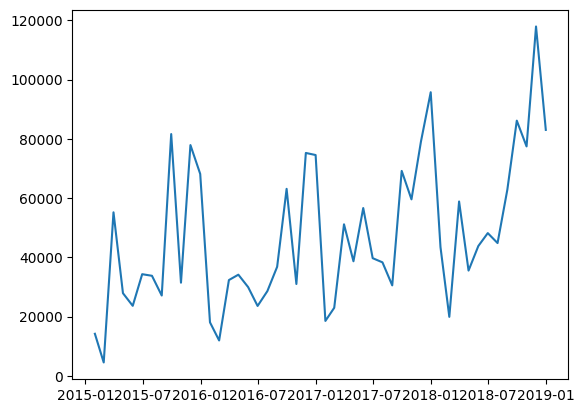

In [78]:
plt.plot(data)
plt.show()

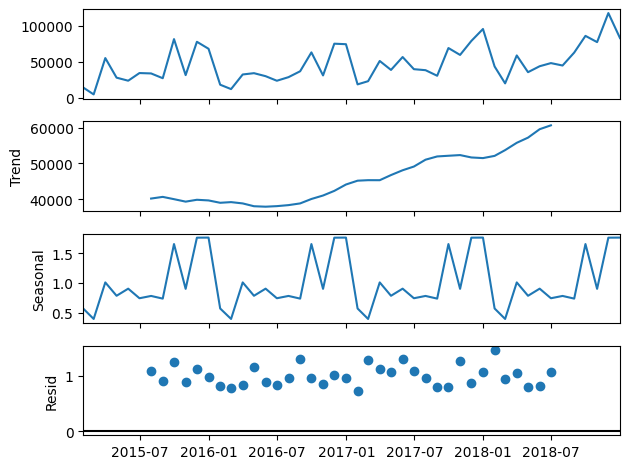

In [80]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data, model='multiplicative')
result.plot()
plt.show()